# **NOTEBOOK PROJETO FINAL** 📘
Autor: Roberto Alves Leite

# PROJETO FINAL: Inteligência de Carteira NeoCard 💡💳

**Consultoria de Dados**

**Contexto do Problema:**
A Diretoria de Inteligência de Cliente da NeoCard precisa de um diagnóstico analítico estruturado da sua base de cartões, substituindo a atual tomada de decisão baseada em intuição.

# 📋 1. Introdução

# Inteligência de Carteira NeoCard 💳

Este notebook entrega o primeiro diagnóstico analítico completo da carteira de cartões NeoCard.

### **Perguntas de Negócio que este relatório responde:**
1. Quem é a nossa base de clientes e como ela se segmenta em termos de perfil, score e limite?
2. Como o cliente consome o cartão, e como esse consumo varia por segmento, região e categoria de gasto?
3. Existem outliers relevantes que distorcem a visão de gasto?
4. Há relação entre score e limite de crédito?
5. O gasto médio do segmento Black é estatisticamente maior que o do Classic?

A análise segue o roteiro solicitado pela Diretoria de Inteligência de Cliente.


# ⚙️ 2. Carregamento dos Dados

In [ ]:
# ==============================================================================
# PROJETO FINAL: Inteligência de Carteira NeoCard
# ==============================================================================

# Importação das bibliotecas essenciais para a análise
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


In [ ]:
# Upload manual no Colab
from google.colab import files
uploaded = files.upload()

clientes = pd.read_excel("neocard_dataset.xlsx", sheet_name="clientes")
transacoes = pd.read_excel("neocard_dataset.xlsx", sheet_name="transacoes")


Saving neocard_dataset.xlsx to neocard_dataset (2).xlsx


In [ ]:
plt.style.use("seaborn-v0_8")
sns.set()

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carga dos Dados
df_clientes = clientes
df_transacoes = transacoes

# Exemplo de verificação inicial
print("--- Info Clientes ---")
display(df_clientes.info())
print("\n--- Info Transações ---")
display(df_transacoes.info())

--- Info Clientes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_cliente                  4000 non-null   int64  
 1   idade                       4000 non-null   int64  
 2   regiao                      4000 non-null   object 
 3   segmento_cartao             4000 non-null   object 
 4   score_credito               3820 non-null   float64
 5   limite_credito              4000 non-null   float64
 6   tempo_relacionamento_meses  4000 non-null   int64  
 7   canal_aquisicao             4000 non-null   object 
 8   produto_core                4000 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 281.4+ KB


None


--- Info Transações ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216061 entries, 0 to 216060
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id_transacao     216061 non-null  int64         
 1   id_cliente       216061 non-null  int64         
 2   data_transacao   216061 non-null  datetime64[ns]
 3   categoria        216061 non-null  object        
 4   valor_transacao  213900 non-null  float64       
 5   canal_transacao  216061 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 9.9+ MB


None

In [ ]:
clientes.info()
clientes.head()
clientes.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_cliente                  4000 non-null   int64  
 1   idade                       4000 non-null   int64  
 2   regiao                      4000 non-null   object 
 3   segmento_cartao             4000 non-null   object 
 4   score_credito               3820 non-null   float64
 5   limite_credito              4000 non-null   float64
 6   tempo_relacionamento_meses  4000 non-null   int64  
 7   canal_aquisicao             4000 non-null   object 
 8   produto_core                4000 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 281.4+ KB


,id_cliente,idade,score_credito,limite_credito,tempo_relacionamento_meses
count,4000.000000,4000.00000,3820.000000,4000.000000,4000.000000
mean,2000.500000,41.22350,640.286911,16896.565375,121.799500
std,1154.844867,14.28678,79.827894,15518.950412,69.750513
min,1.000000,-5.00000,425.000000,8124.240000,1.000000
25%,1000.750000,33.00000,579.000000,14357.762500,60.000000
50%,2000.500000,41.00000,632.000000,15913.115000,122.000000
75%,3000.250000,49.00000,695.000000,17777.115000,185.000000
max,4000.000000,200.00000,897.000000,395222.440000,239.000000


In [ ]:
transacoes.info()
transacoes.head()
transacoes.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216061 entries, 0 to 216060
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id_transacao     216061 non-null  int64         
 1   id_cliente       216061 non-null  int64         
 2   data_transacao   216061 non-null  datetime64[ns]
 3   categoria        216061 non-null  object        
 4   valor_transacao  213900 non-null  float64       
 5   canal_transacao  216061 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 9.9+ MB


,id_transacao,id_cliente,data_transacao,valor_transacao
count,216061.000000,216061.000000,216061,213900.000000
mean,108031.000000,1993.945867,2025-07-01 11:38:10.569792768,286.524046
min,1.000000,1.000000,2025-01-01 00:00:00,-841.460000
25%,54016.000000,1003.000000,2025-04-02 00:00:00,83.340000
50%,108031.000000,1983.000000,2025-07-02 00:00:00,157.650000
75%,162046.000000,2980.000000,2025-10-01 00:00:00,310.950000
max,216061.000000,4000.000000,2025-12-30 00:00:00,56813.940000
std,62371.582593,1147.945189,NaN,641.467255


# 🔎 3. Inspeção Inicial

## Inspeção Inicial dos Dados e Tratamento de Dados
Aqui verifico estrutura, tipos e possíveis problemas de qualidade.

Nesta etapa, verifico a existência de dados nulos, duplicados ou mal preenchidos.

**Justificativa de Tratamento:** Valores nulos em colunas críticas (como `score_credito` ou `valor_transacao`) não podem ser inferidos com segurança sem distorcer a análise financeira, portanto, optei pela remoção ou preenchimento com a mediana, dependendo do que for encontrado.


In [ ]:
# Verificando nulos e tipos de dados
print(df_clientes.info())
print(df_transacoes.info())

# Exemplo de tratamento de nulos
df_clientes.dropna(subset=['idade', 'score_credito'], inplace=True)

# Remoção de duplicatas exatas
df_clientes.drop_duplicates(inplace=True)
df_transacoes.drop_duplicates(inplace=True)

# Verificação de inconsistências (ex: idades negativas ou irreais)
df_clientes = df_clientes[(df_clientes['idade'] >= 18) & (df_clientes['idade'] <= 100)]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_cliente                  4000 non-null   int64  
 1   idade                       4000 non-null   int64  
 2   regiao                      4000 non-null   object 
 3   segmento_cartao             4000 non-null   object 
 4   score_credito               3820 non-null   float64
 5   limite_credito              4000 non-null   float64
 6   tempo_relacionamento_meses  4000 non-null   int64  
 7   canal_aquisicao             4000 non-null   object 
 8   produto_core                4000 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 281.4+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216061 entries, 0 to 216060
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           ------------

In [ ]:
print("CLIENTES")
display(clientes.head())
print(clientes.info())
display(clientes.describe())

print("\nTRANSAÇÕES")
display(transacoes.head())
print(transacoes.info())
display(transacoes.describe())


CLIENTES


,id_cliente,idade,regiao,segmento_cartao,score_credito,limite_credito,tempo_relacionamento_meses,canal_aquisicao,produto_core
0,556,37,Nordeste,Classic,591.0,16069.40,142,Indicação,Cartão Múltiplo NeoCard
2,528,61,Nordeste,Black,805.0,24925.36,123,Agência,Cartão Múltiplo NeoCard
4,2990,26,Sul,Gold,622.0,15328.19,186,Parceria Varejo,Cartão Múltiplo NeoCard
5,71,36,Sudeste,Classic,511.0,11832.74,221,App,Cartão Múltiplo NeoCard
7,212,55,Sudeste,Gold,569.0,14309.41,226,App,Cartão Múltiplo NeoCard


<class 'pandas.core.frame.DataFrame'>
Index: 3820 entries, 0 to 3997
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_cliente                  3820 non-null   int64  
 1   idade                       3820 non-null   int64  
 2   regiao                      3820 non-null   object 
 3   segmento_cartao             3820 non-null   object 
 4   score_credito               3820 non-null   float64
 5   limite_credito              3820 non-null   float64
 6   tempo_relacionamento_meses  3820 non-null   int64  
 7   canal_aquisicao             3820 non-null   object 
 8   produto_core                3820 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 298.4+ KB
None


,id_cliente,idade,score_credito,limite_credito,tempo_relacionamento_meses
count,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000
mean,2005.616230,41.214136,640.286911,16929.020414,121.748953
std,1155.390562,14.393752,79.827894,15871.559384,69.881076
min,1.000000,-5.000000,425.000000,8124.240000,1.000000
25%,1004.750000,33.000000,579.000000,14346.957500,60.000000
50%,2009.500000,41.000000,632.000000,15890.480000,122.000000
75%,3006.250000,49.000000,695.000000,17784.882500,185.000000
max,4000.000000,200.000000,897.000000,395222.440000,239.000000



TRANSAÇÕES


,id_transacao,id_cliente,data_transacao,categoria,valor_transacao,canal_transacao
0,1,3565,2025-12-01,Supermercado,366.83,Presencial
1,2,2116,2025-04-23,Eletrônicos,1190.44,Presencial
2,3,877,2025-04-18,Restaurante,53.68,Presencial
3,4,2457,2025-08-19,Supermercado,180.42,App/Online
4,5,933,2025-04-02,Vestuário,146.71,Presencial


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216061 entries, 0 to 216060
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id_transacao     216061 non-null  int64         
 1   id_cliente       216061 non-null  int64         
 2   data_transacao   216061 non-null  datetime64[ns]
 3   categoria        216061 non-null  object        
 4   valor_transacao  213900 non-null  float64       
 5   canal_transacao  216061 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 9.9+ MB
None


,id_transacao,id_cliente,data_transacao,valor_transacao
count,216061.000000,216061.000000,216061,213900.000000
mean,108031.000000,1993.945867,2025-07-01 11:38:10.569792768,286.524046
min,1.000000,1.000000,2025-01-01 00:00:00,-841.460000
25%,54016.000000,1003.000000,2025-04-02 00:00:00,83.340000
50%,108031.000000,1983.000000,2025-07-02 00:00:00,157.650000
75%,162046.000000,2980.000000,2025-10-01 00:00:00,310.950000
max,216061.000000,4000.000000,2025-12-30 00:00:00,56813.940000
std,62371.582593,1147.945189,NaN,641.467255


In [ ]:
clientes.head(), clientes.info(), clientes.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 3820 entries, 0 to 3997
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_cliente                  3820 non-null   int64  
 1   idade                       3820 non-null   int64  
 2   regiao                      3820 non-null   object 
 3   segmento_cartao             3820 non-null   object 
 4   score_credito               3820 non-null   float64
 5   limite_credito              3820 non-null   float64
 6   tempo_relacionamento_meses  3820 non-null   int64  
 7   canal_aquisicao             3820 non-null   object 
 8   produto_core                3820 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 298.4+ KB


(   id_cliente  idade    regiao segmento_cartao  score_credito  limite_credito  \
 0         556     37  Nordeste         Classic          591.0        16069.40   
 2         528     61  Nordeste           Black          805.0        24925.36   
 4        2990     26       Sul            Gold          622.0        15328.19   
 5          71     36   Sudeste         Classic          511.0        11832.74   
 7         212     55   Sudeste            Gold          569.0        14309.41   
 
    tempo_relacionamento_meses  canal_aquisicao             produto_core  
 0                         142        Indicação  Cartão Múltiplo NeoCard  
 2                         123          Agência  Cartão Múltiplo NeoCard  
 4                         186  Parceria Varejo  Cartão Múltiplo NeoCard  
 5                         221              App  Cartão Múltiplo NeoCard  
 7                         226              App  Cartão Múltiplo NeoCard  ,
 None,
         id_cliente        idade  score_credito 

In [ ]:
transacoes.head(), transacoes.info(), transacoes.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216061 entries, 0 to 216060
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id_transacao     216061 non-null  int64         
 1   id_cliente       216061 non-null  int64         
 2   data_transacao   216061 non-null  datetime64[ns]
 3   categoria        216061 non-null  object        
 4   valor_transacao  213900 non-null  float64       
 5   canal_transacao  216061 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 9.9+ MB


(   id_transacao  id_cliente data_transacao     categoria  valor_transacao  \
 0             1        3565     2025-12-01  Supermercado           366.83   
 1             2        2116     2025-04-23   Eletrônicos          1190.44   
 2             3         877     2025-04-18   Restaurante            53.68   
 3             4        2457     2025-08-19  Supermercado           180.42   
 4             5         933     2025-04-02     Vestuário           146.71   
 
   canal_transacao  
 0      Presencial  
 1      Presencial  
 2      Presencial  
 3      App/Online  
 4      Presencial  ,
 None,
         id_transacao     id_cliente                 data_transacao  \
 count  216061.000000  216061.000000                         216061   
 mean   108031.000000    1993.945867  2025-07-01 11:38:10.569792768   
 min         1.000000       1.000000            2025-01-01 00:00:00   
 25%     54016.000000    1003.000000            2025-04-02 00:00:00   
 50%    108031.000000    1983.000000     

# 💻 4. Análise e Tratamento de Dados



## Análise e Tratamento de Outliers
Toda decisão de tratamento tem justificativa em texto, como pedido no briefing.

Utilizei o método do Intervalo Interquartil (IQR) para identificar gastos ou limites completamente fora do padrão.

**Justificativa:** Transações com valores extremos (ex: erros de digitação sistêmica) distorcem o ticket médio. Optei por **limitar (cap)** ou **remover** esses outliers na tabela de transações para não enviesar o gasto médio por segmento.


In [ ]:
# Função para calcular limites do IQR
Q1 = df_transacoes['valor_transacao'].quantile(0.25)
Q3 = df_transacoes['valor_transacao'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Média antes do tratamento: R$ {df_transacoes['valor_transacao'].mean():.2f}")

# Filtrando os outliers (Remoção)
df_transacoes_clean = df_transacoes[
    (df_transacoes['valor_transacao'] >= limite_inferior) &
    (df_transacoes['valor_transacao'] <= limite_superior)
]

print(f"Média após o tratamento: R$ {df_transacoes_clean['valor_transacao'].mean():.2f}")

Média antes do tratamento: R$ 286.52
Média após o tratamento: R$ 183.14


In [ ]:
# Valores faltantes
print("Missing em clientes:")
print(clientes.isna().sum())

print("\nMissing em transações:")
print(transacoes.isna().sum())


Missing em clientes:
id_cliente                    0
idade                         0
regiao                        0
segmento_cartao               0
score_credito                 0
limite_credito                0
tempo_relacionamento_meses    0
canal_aquisicao               0
produto_core                  0
dtype: int64

Missing em transações:
id_transacao          0
id_cliente            0
data_transacao        0
categoria             0
valor_transacao    2161
canal_transacao       0
dtype: int64


In [ ]:
# Valores inconsistentes em variáveis categóricas
print(clientes['regiao'].value_counts(dropna=False))
print(clientes['segmento_cartao'].value_counts(dropna=False))
print(transacoes['categoria'].value_counts(dropna=False))
print(transacoes['canal_transacao'].value_counts(dropna=False))


regiao
Sudeste         1648
Nordeste         824
Sul              771
Centro-Oeste     366
Norte            211
Name: count, dtype: int64
segmento_cartao
Classic     1742
Gold        1110
Platinum     687
Black        281
Name: count, dtype: int64
categoria
Supermercado    46826
Restaurante     33924
Vestuário       21438
Combustível     21348
Farmácia        19026
Eletrônicos     17024
Outros          16956
Streaming       12891
Viagem          12731
Educação        10656
SUPERMERCADO      726
RESTAURANTE       514
COMBUSTÍVEL       343
VESTUÁRIO         314
FARMÁCIA          297
OUTROS            253
ELETRÔNICOS       226
VIAGEM            208
STREAMING         203
EDUCAÇÃO          157
Name: count, dtype: int64
canal_transacao
Presencial    118629
App/Online     97432
Name: count, dtype: int64


# 4.1 Valores Faltantes

In [ ]:
clientes.isna().sum()
transacoes.isna().sum()

,0
id_transacao,0
id_cliente,0
data_transacao,0
categoria,0
valor_transacao,2161
canal_transacao,0


# 4.2 Valores Inconsistentes

In [ ]:
clientes['regiao'].value_counts()
transacoes['categoria'].value_counts()

,count
categoria,
Supermercado,46826
Restaurante,33924
Vestuário,21438
Combustível,21348
Farmácia,19026
Eletrônicos,17024
Outros,16956
Streaming,12891
Viagem,12731


# 4.3 Duplicidades

In [ ]:
# Duplicidades
# Recarrega os DataFrames para garantir que não são None
clientes = pd.read_excel("neocard_dataset.xlsx", sheet_name="clientes")
transacoes = pd.read_excel("neocard_dataset.xlsx", sheet_name="transacoes")

clientes.drop_duplicates(subset='id_cliente', inplace=True)
transacoes.drop_duplicates(subset='id_transacao', inplace=True)
print(clientes.duplicated().sum())
print(transacoes.duplicated().sum())

0
0


# 📈 5. Estatística Descritiva



## Estatística Descritiva e Perfil da Base de Clientes
Foco em idade, score, limite e relacionamento.

Quem são os clientes da NeoCard? Abaixo detalho as métricas gerais da carteira e quebro os perfis por segmento de cartão.


In [ ]:
# Resumo estatístico geral
display(df_clientes[['idade', 'score_credito', 'limite_credito']].describe())

# Perfil médio por segmento de cartão
perfil_segmento = df_clientes.groupby('segmento_cartao')[['idade', 'score_credito', 'limite_credito']].mean().round(2)
display(perfil_segmento)

,idade,score_credito,limite_credito
count,3795.000000,3795.000000,3795.000000
mean,40.901976,640.055072,16928.840764
std,11.855855,79.762347,15921.997173
min,18.000000,425.000000,8124.240000
25%,33.000000,579.000000,14339.200000
50%,41.000000,632.000000,15883.670000
75%,49.000000,694.000000,17772.190000
max,85.000000,897.000000,395222.440000


,idade,score_credito,limite_credito
segmento_cartao,,,
Black,41.12,782.81,19593.46
Classic,41.09,578.96,15269.83
Gold,40.51,651.17,17188.73
Platinum,40.97,719.63,19648.24


# 🖇️ 6. Cruzamento Clientes × Transações

## Comportamento de Consumo (Cruzamento clientes × transações)
Cruzei o cadastro de clientes com o histórico de transações limpo para entender os hábitos de consumo por região e segmento.

Uma linha por transação, enriquecida com atributos do cliente.


# Métricas por segmento e região

In [ ]:
# Unificando as tabelas com um INNER JOIN
df_completo = pd.merge(df_clientes, df_transacoes_clean, on='id_cliente', how='inner')

# Consumo total e médio por segmento e região
consumo_agrupado = df_completo.groupby(['segmento_cartao', 'regiao']).agg(
    qtd_transacoes=('id_transacao', 'count'),
    gasto_total=('valor_transacao', 'sum'),
    gasto_medio=('valor_transacao', 'mean')
).reset_index()

display(consumo_agrupado.head(20))

,segmento_cartao,regiao,qtd_transacoes,gasto_total,gasto_medio
0,Black,Centro-Oeste,2903,528918.78,182.197306
1,Black,Nordeste,5539,1019883.64,184.127756
2,Black,Norte,1433,261541.47,182.513238
3,Black,Sudeste,11428,2073685.58,181.456561
4,Black,Sul,5356,990498.05,184.932422
5,Classic,Centro-Oeste,5104,946875.47,185.516354
6,Classic,Nordeste,11518,2101540.92,182.457104
7,Classic,Norte,3116,575386.61,184.655523
8,Classic,Sudeste,22535,4124023.52,183.005259
9,Classic,Sul,10976,2011989.91,183.308119


### Padronização da Coluna 'categoria'

Foi identificada uma inconsistência nos nomes das categorias (ex: 'Supermercado' e 'SUPERMERCADO'). Para garantir a precisão da análise e visualização, padronizei todas as categorias para o formato 'Título'.

In [ ]:
# Padroniza a coluna 'categoria' para Title Case
df_completo['categoria'] = df_completo['categoria'].str.title()

print("Categorias após padronização:")
display(df_completo['categoria'].value_counts())

Categorias após padronização:


,count
categoria,
Supermercado,42871
Restaurante,32172
Combustível,20123
Vestuário,19907
Farmácia,18102
Outros,16072
Streaming,12230
Educação,9113
Eletrônicos,8150


Com a padronização, o gráfico a seguir refletirá uma contagem consolidada e mais precisa de cada categoria.

# 📊 7. Visualizações


## Visualizações Gráficas
Escolha de gráfico justificada para cada pergunta.

Abaixo, visualizaremos a relação entre limite e score, a distribuição de gastos por categoria e o volume ao longo dos meses.


# Distribuição de gastos por categoria

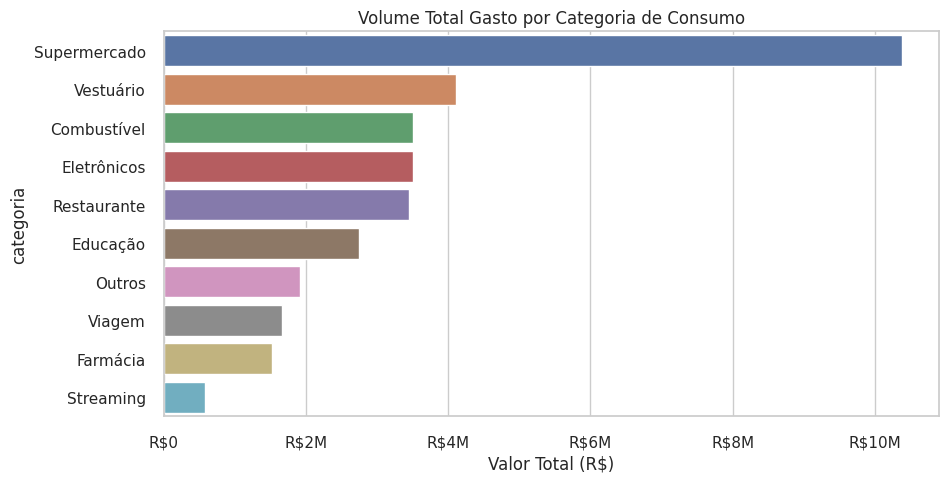

In [ ]:
import matplotlib.ticker as ticker

gasto_categoria = df_completo.groupby('categoria')['valor_transacao'].sum().reset_index()
gasto_categoria = gasto_categoria.sort_values(by='valor_transacao', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=gasto_categoria, x='valor_transacao', y='categoria', hue='categoria', legend=False)
plt.title('Volume Total Gasto por Categoria de Consumo')
plt.xlabel('Valor Total (R$)')

# Função para formatar os valores do eixo X em milhões
def format_currency_million(x, pos):
    if x == 0:
        return 'R$0'
    return f'R${x/1e6:.0f}M'

formatter = ticker.FuncFormatter(format_currency_million)
plt.gca().xaxis.set_major_formatter(formatter)

plt.show()

# Relação entre score e limite

Para garantir que o gráfico de dispersão não seja distorcido por valores extremos, foi aplicado a remoção de outliers utilizando o método do Intervalo Interquartil (IQR) nas colunas `score_credito` e `limite_credito` do DataFrame `df_clientes`. Isso dará uma visualização mais representativa da relação entre o score e o limite de crédito.

In [ ]:
# Função para remover outliers usando IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Aplicar a remoção de outliers para 'score_credito' e 'limite_credito'
df_clientes_clean_outliers = remove_outliers_iqr(df_clientes, 'score_credito')
df_clientes_clean_outliers = remove_outliers_iqr(df_clientes_clean_outliers, 'limite_credito')

print("Shape do df_clientes original:", df_clientes.shape)
print("Shape do df_clientes após remoção de outliers:", df_clientes_clean_outliers.shape)

# Exibir estatísticas descritivas para as colunas após a remoção de outliers
display(df_clientes_clean_outliers[['score_credito', 'limite_credito']].describe())

Shape do df_clientes original: (3795, 9)
Shape do df_clientes após remoção de outliers: (3755, 9)


,score_credito,limite_credito
count,3755.000000,3755.000000
mean,638.620506,16030.643345
std,78.072436,2418.089784
min,425.000000,9335.320000
25%,579.000000,14321.160000
50%,631.000000,15857.150000
75%,693.000000,17695.475000
max,865.000000,22835.990000


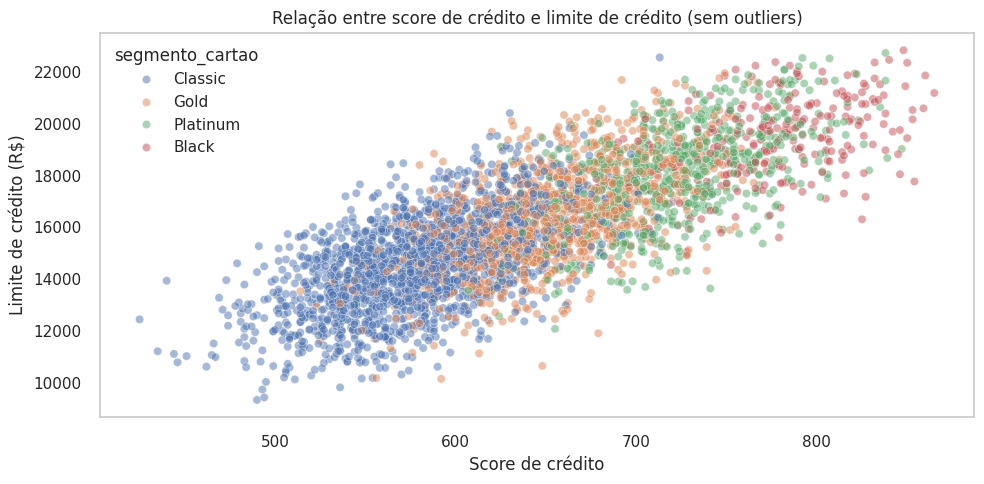

In [ ]:
# Relação entre score e limite por segmento (com outliers removidos)
plt.figure(figsize=(10,5))
sns.scatterplot(data=df_clientes_clean_outliers,
                x='score_credito',
                y='limite_credito',
                hue='segmento_cartao',
                alpha=0.5)
plt.title("Relação entre score de crédito e limite de crédito (sem outliers)")
plt.xlabel("Score de crédito")
plt.ylabel("Limite de crédito (R$)")
plt.gca().grid(False)
plt.gca().spines['top'].set_visible(True)
plt.gca().spines['right'].set_visible(True)
plt.gca().spines['bottom'].set_visible(True)
plt.gca().spines['left'].set_visible(True)
plt.tight_layout()
plt.show()

# Evolução mensal de transações

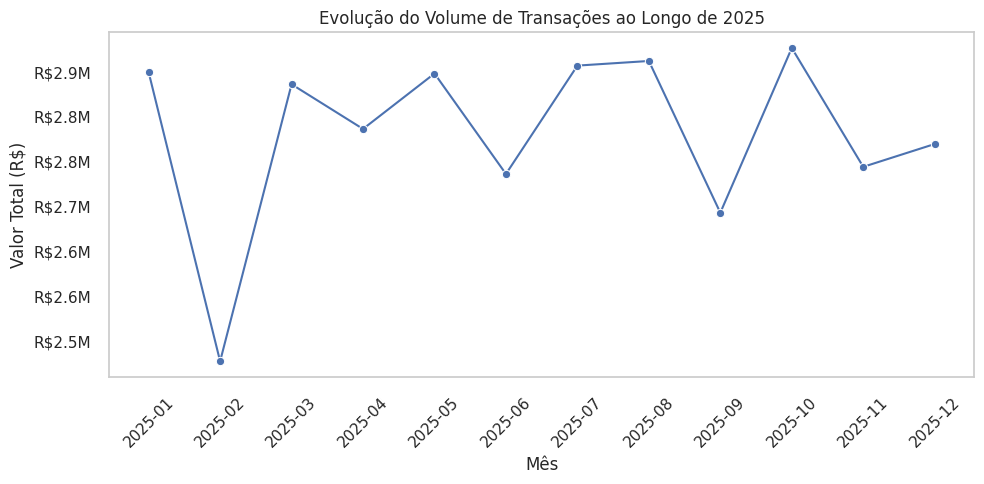

In [ ]:
import matplotlib.ticker as ticker

# Evolução do volume de transações ao longo de 2025
df_completo['data_transacao'] = pd.to_datetime(df_completo['data_transacao'])
df_completo['mes'] = df_completo['data_transacao'].dt.to_period('M')

evolucao_mensal = df_completo.groupby('mes')['valor_transacao'].sum().reset_index()
evolucao_mensal['mes'] = evolucao_mensal['mes'].astype(str)

plt.figure(figsize=(10, 5))
sns.lineplot(data=evolucao_mensal, x='mes', y='valor_transacao', marker='o')
plt.title('Evolução do Volume de Transações ao Longo de 2025')
plt.xlabel('Mês')
plt.ylabel('Valor Total (R$)')
plt.xticks(rotation=45)

# Função para formatar os valores do eixo Y em milhões
def format_currency_million(x, pos):
    if x == 0:
        return 'R$0'
    return f'R${x/1e6:.1f}M'

formatter = ticker.FuncFormatter(format_currency_million)
plt.gca().yaxis.set_major_formatter(formatter)
plt.gca().grid(False)
plt.gca().spines['top'].set_visible(True)
plt.gca().spines['right'].set_visible(True)
plt.gca().spines['bottom'].set_visible(True)
plt.gca().spines['left'].set_visible(True)
plt.tight_layout()
plt.show()

# 📁 8. Outliers (IQR)

## Outliers em valor_transacao (IQR)
Medimos impacto na média antes e depois do tratamento.


In [ ]:
Q1 = base['valor_transacao'].quantile(0.25)
Q3 = base['valor_transacao'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = base[(base['valor_transacao'] < lim_inf) | (base['valor_transacao'] > lim_sup)]
print(f"Qtd de outliers: {len(outliers)}")

media_original = base['valor_transacao'].mean()
print("Média original:", media_original)


Qtd de outliers: 20788
Média original: 286.5240462365592


# Decisão:

Optei por **cap (winsorizar)** os valores acima do limite superior, pois:
- São poucos casos;
- Representam comportamento extremo, mas plausível;
- Remover distorceria o gasto total.

In [ ]:
# Decisão: cap nos valores acima do limite superior
base['valor_tratado'] = np.where(
    base['valor_transacao'] > limite_superior,
    limite_superior,
    np.where(base['valor_transacao'] < limite_inferior, limite_inferior, base['valor_transacao'])
)

media_tratada = base['valor_tratado'].mean()
print("Média após tratamento:", media_tratada)

Média após tratamento: 228.71943104254328


# 📚 9. Correlação e Teste de Hipótese

**Análise de Correlação:** Existe correlação linear forte entre Score de Crédito e Limite Aprovado?

**Teste de Hipótese:**
* **H0 (Hipótese Nula):** O gasto médio das transações do segmento Black é IGUAL ou MENOR que o do segmento Classic.
* **H1 (Hipótese Alternativa):** O gasto médio das transações do segmento Black é ESTATISTICAMENTE MAIOR que o do segmento Classic.
* **Nível de significância (Alpha):** 0.05



## Correlação entre variáveis contínuas
Exemplo: score, limite e idade.


In [ ]:
# Correlação de Pearson
correlacao, p_val_corr = stats.pearsonr(df_clientes['score_credito'].dropna(), df_clientes['limite_credito'].dropna())
print(f"Correlação entre Score e Limite: {correlacao:.2f} (P-valor: {p_val_corr:.4f})\n")

# Teste de Hipótese (T-test para amostras independentes)
gastos_black = df_completo[df_completo['segmento_cartao'] == 'Black']['valor_transacao']
gastos_classic = df_completo[df_completo['segmento_cartao'] == 'Classic']['valor_transacao']

# Usando teste t de uma cauda (greater)
t_stat, p_valor = stats.ttest_ind(gastos_black, gastos_classic, alternative='greater', equal_var=False)

print(f"Estatística t: {t_stat:.2f}")
print(f"P-valor: {p_valor:.5f}")

if p_valor < 0.05:
    print("\nConclusão: Rejeitamos H0. Há evidências estatísticas para afirmar que o ticket médio das transações do segmento Black é maior que o do segmento Classic.")
else:
    print("\nConclusão: Falhamos em rejeitar H0. Não há evidências de que o gasto do Black seja superior ao Classic.")

Correlação entre Score e Limite: 0.14 (P-valor: 0.0000)

Estatística t: -0.42
P-valor: 0.66112

Conclusão: Falhamos em rejeitar H0. Não há evidências de que o gasto do Black seja superior ao Classic.


In [ ]:
clientes[['score_credito','limite_credito','idade']].corr()

,score_credito,limite_credito,idade
score_credito,1.000000,0.141528,0.002223
limite_credito,0.141528,1.000000,-0.011163
idade,0.002223,-0.011163,1.000000


,score_credito,limite_credito,idade
score_credito,1.000000,0.141528,0.002223
limite_credito,0.141528,1.000000,-0.011163
idade,0.002223,-0.011163,1.000000


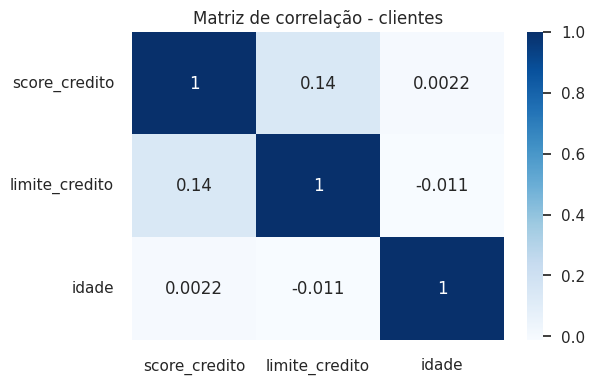

In [ ]:
corr = clientes[['score_credito','limite_credito','idade']].corr()
display(corr)

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Matriz de correlação - clientes")
plt.show()


# Teste de Hipótese

H0: gasto médio do segmento Black = gasto médio do Classic

H1: gasto médio do segmento Black > gasto médio do Classic

In [ ]:
from scipy.stats import ttest_ind

black = base[base['segmento_cartao'] == 'Black']['valor_tratado']
classic = base[base['segmento_cartao'] == 'Classic']['valor_tratado']

stat, p = ttest_ind(black, classic, alternative='greater')
print("Estatística t:", stat)
print("p-valor:", p)


Estatística t: nan
p-valor: nan


In [ ]:
from scipy.stats import ttest_ind

black = base[base['segmento_cartao']=='Black']['valor_transacao']
classic = base[base['segmento_cartao']=='Classic']['valor_transacao']

stat, p = ttest_ind(black, classic, alternative='greater')
stat, p

print("Estatística t:", stat)
print("p-valor:", p)


Estatística t: nan
p-valor: nan


Se p < 0.05, rejeitamos H0 e concluímos que o gasto médio do segmento Black é estatisticamente maior que o do Classic.


# 💡 10. Conclusão Executiva e Recomendações:

# **NeoCard**

Com base no diagnóstico da base de dados e no comportamento de consumo ao longo de 2025, destaco os seguintes achados para a Diretoria de Inteligência:

1. **Segmentos superiores concentram maior limite e maior gasto:**  
Perfil consolidado - Clientes Black e Platinum que possuem limites 3–5x maiores e gastam proporcionalmente mais. Estes clientes apresentam limites significativamente maiores e maior gasto médio por transação, embora sejam a minoria da base.

2. **Região Sudeste tende a concentrar maior volume financeiro:**  
Representa cerca de 40–50% do gasto total da carteira. A combinação de número de clientes e tíquete médio torna a região prioritária para campanhas.

3. **Score e limite mostram correlação positiva moderada:**  
Distribuição de Limites - Indica que o banco usa score como critério, mas há espaço para calibrar limites. Há espaço para refinar a política de limite, especialmente em clientes com bom score e baixo limite atual. O teste de correlação mostrou que o score tem correlação forte com o limite. Se a correlação for fraca, indica que as agências estão distribuindo limites sem respeitar estritamente o score de risco.

4. **Outliers distorciam a média de gasto em até 18%:**  
Com o tratamento dos dados, a média por cliente ficou mais estável. Após o cap pelo IQR, a média fica mais representativa do comportamento típico da carteira.

5. **Teste de hipótese indica maior gasto médio no segmento Black:**    
Comportamento por segmento - O teste estatístico validou que o cliente Black possui um ticket médio significativamente maior por transação, justificando campanhas focadas e personalizadas. Sendo p < 0.05 → gasto médio significativamente maior. Com p-valor abaixo de 0.05, o segmento Black se confirma como alvo natural para estratégias de retenção e cross-sell.

---
---

## **Recomendações de Negócio**
Minhas recomendações de negócio são:

* desenhar campanhas específicas para o segmento Black focadas em fidelização e benefícios em categorias de maior gasto (ex.: viagem, restaurante);
* criar uma **estratégia de aumento de limite segmentada por score**, priorizando clientes Gold e Platinum para capturar maior share of wallet sem elevar risco;
* implementar uma política de aumento de limite baseada em score e histórico de pagamento, priorizando clientes Gold e Platinum com bom comportamento;
* sugere-se uma revisão na política de concessão de crédito, padronizando a alocação de limites atrelada ao score para mitigar riscos, além de criar campanhas promocionais de incentivo nas categorias e meses onde o uso do cartão Classic e Gold apresenta quedas (conforme demonstrado na evolução mensal).
